<a href="https://colab.research.google.com/github/JEEVAA0107/Action-Recognition/blob/main/Action_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cpu
GPU available: False


In [7]:
!pip install -q opencv-python
!pip install -q scikit-learn
!pip install -q matplotlib
!pip install -q pandas

In [8]:
import cv2
import torch
import sklearn
import matplotlib
import pandas

print("OpenCV:", cv2.__version__)
print("PyTorch:", torch.__version__)
print("Setup successful!")

OpenCV: 5.0.0
PyTorch: 2.11.0+cpu
Setup successful!


In [9]:
PROJECT_NAME = "Action Recognition in Videos"
DATASET_NAME = "UCF101"

NUM_FRAMES = 16
IMAGE_SIZE = 112

print("Project:", PROJECT_NAME)
print("Dataset:", DATASET_NAME)
print("Frames:", NUM_FRAMES)
print("Image Size:", IMAGE_SIZE)

Project: Action Recognition in Videos
Dataset: UCF101
Frames: 16
Image Size: 112


In [10]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [11]:
import os

folders = [
    "data",
    "models",
    "preprocessing",
    "training",
    "evaluation",
    "inference",
    "outputs",
    "checkpoints"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [12]:
!wget --no-check-certificate --show-progress "https://www.crcv.ucf.edu/data/UCF101/UCF101.rar"

--2026-08-13 04:54:07--  https://www.crcv.ucf.edu/data/UCF101/UCF101.rar
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
  Unable to locally verify the issuer's authority.
HTTP request sent, awaiting response... 200 OK
Length: 6932971618 (6.5G) [application/x-rar-compressed]
Saving to: ‘UCF101.rar’

UCF101.rar          100%[===================>]   6.46G   107MB/s    in 1m 40s  

2026-08-13 04:55:47 (66.4 MB/s) - ‘UCF101.rar’ saved [6932971618/6932971618]



In [13]:
import os

print("File exists:", os.path.exists("UCF101.rar"))

if os.path.exists("UCF101.rar"):
    size_gb = os.path.getsize("UCF101.rar") / (1024**3)
    print(f"File size: {size_gb:.2f} GB")

File exists: True
File size: 6.46 GB


In [14]:
!which unrar

/usr/bin/unrar


In [15]:
!unrar


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal

Usage:     unrar <command> -<switch 1> -<switch N> <archive> <files...>
               <@listfiles...> <path_to_extract\>

<Commands>
  e             Extract files without archived paths
  l[t[a],b]     List archive contents [technical[all], bare]
  p             Print file to stdout
  t             Test archive files
  v[t[a],b]     Verbosely list archive contents [technical[all],bare]
  x             Extract files with full path

<Switches>
  -             Stop switches scanning
  @[+]          Disable [enable] file lists
  ad[1,2]       Alternate destination path
  ag[format]    Generate archive name using the current date
  ai            Ignore file attributes
  ap<path>      Set path inside archive
  c-            Disable comments show
  cfg-          Disable read configuration
  cl            Convert names to lower case
  cu            Convert names to upper case
  dh            Open shared files
  ep     

In [16]:
import os

os.makedirs("data/UCF101", exist_ok=True)

print("Folder ready:", os.path.exists("data/UCF101"))

Folder ready: True


In [17]:
!unrar x -o+ UCF101.rar data/UCF101/

Streaming output truncated to the last 5000 lines.
Extracting  data/UCF101/UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c05.avi      62%  OK 
Extracting  data/UCF101/UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c06.avi      62%  OK 
Extracting  data/UCF101/UCF-101/PlayingGuitar/v_PlayingGuitar_g06_c07.avi      62%  OK 
Extracting  data/UCF101/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c01.avi      62%  OK 
Extracting  data/UCF101/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c02.avi      62%  OK 
Extracting  data/UCF101/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c03.avi      62%  OK 
Extracting  data/UCF101/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c04.avi      62%  OK 
Extracting  data/UCF101/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c05.avi      62%  OK 
Extracting  data/UCF101/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c06.avi      62%  OK 
Extracting  data/UCF101/UCF-101/PlayingGuitar/v_PlayingGuitar_g07_c07.avi   

In [18]:
import os

dataset_path = "data/UCF101"

classes = [
    folder for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("Number of classes:", len(classes))
print("First 10 classes:")

for c in sorted(classes)[:10]:
    print(c)

Number of classes: 1
First 10 classes:
UCF-101


In [19]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles/Folders in current directory:")
for item in os.listdir("."):
    print(item)

Current folder:
/content

Files/Folders in current directory:
.config
data
checkpoints
inference
ucf101_dataset
UCF101.rar
outputs
models
training
preprocessing
evaluation
sample_data


In [20]:
import os

dataset_path = "ucf101_dataset"

print("Dataset folder exists:", os.path.exists(dataset_path))

if os.path.exists(dataset_path):
    print("\nInside ucf101_dataset:")
    for item in os.listdir(dataset_path)[:20]:
        print(item)

Dataset folder exists: True

Inside ucf101_dataset:
UCF-101


In [21]:
import os

dataset_path = "ucf101_dataset/UCF-101"

print("Dataset path exists:", os.path.exists(dataset_path))

if os.path.exists(dataset_path):
    items = os.listdir(dataset_path)

    print("Number of items:", len(items))
    print("\nFirst 10 items:")

    for item in items[:10]:
        print(item)

Dataset path exists: True
Number of items: 101

First 10 items:
PlayingViolin
Lunges
HandstandPushups
Knitting
Rafting
PlayingFlute
TableTennisShot
HorseRiding
BlowingCandles
HighJump


In [22]:
import os

dataset_path = "ucf101_dataset/UCF-101"

selected_class = None
selected_video = None

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue

    for file_name in sorted(os.listdir(class_path)):
        if file_name.lower().endswith((".avi", ".mp4", ".mov")):
            selected_class = class_name
            selected_video = os.path.join(class_path, file_name)
            break

    if selected_video:
        break

print("Selected Class:", selected_class)
print("Selected Video:", selected_video)

Selected Class: ApplyEyeMakeup
Selected Video: ucf101_dataset/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g01_c01.avi


In [23]:
import cv2

cap = cv2.VideoCapture(selected_video)

print("Video opened:", cap.isOpened())

if cap.isOpened():
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print("FPS:", fps)
    print("Total Frames:", frame_count)
    print("Resolution:", width, "x", height)

cap.release()

Video opened: True
FPS: 25.0
Total Frames: 164
Resolution: 320 x 240


In [24]:
import cv2

cap = cv2.VideoCapture(selected_video)

frames = []

while True:
    success, frame = cap.read()

    if not success:
        break

    frames.append(frame)

cap.release()

print("Total frames extracted:", len(frames))

Total frames extracted: 164


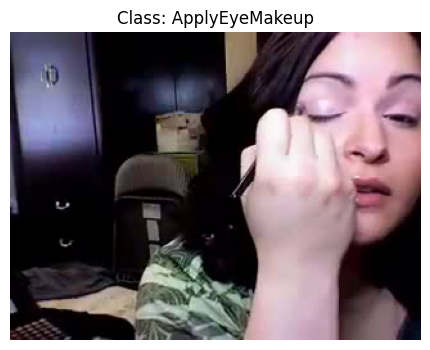

In [25]:
import matplotlib.pyplot as plt
import cv2

first_frame = frames[0]

first_frame_rgb = cv2.cvtColor(
    first_frame,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(6, 4))
plt.imshow(first_frame_rgb)
plt.axis("off")
plt.title(f"Class: {selected_class}")
plt.show()

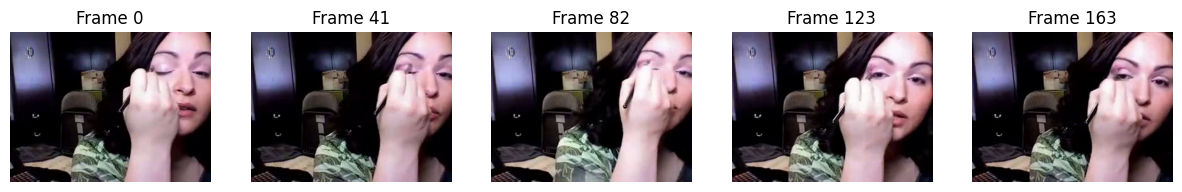

In [26]:
import matplotlib.pyplot as plt
import cv2

num_frames = len(frames)

indices = [
    0,
    num_frames // 4,
    num_frames // 2,
    (3 * num_frames) // 4,
    num_frames - 1
]

plt.figure(figsize=(15, 3))

for i, idx in enumerate(indices):
    frame_rgb = cv2.cvtColor(
        frames[idx],
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(1, 5, i + 1)
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.title(f"Frame {idx}")

plt.show()

In [27]:
import numpy as np

NUM_FRAMES = 16

total_frames = len(frames)

indices = np.linspace(
    0,
    total_frames - 1,
    NUM_FRAMES
).astype(int)

sampled_frames = [frames[i] for i in indices]

print("Original frames:", total_frames)
print("Sampled frames:", len(sampled_frames))
print("Selected indices:", indices)

Original frames: 164
Sampled frames: 16
Selected indices: [  0  10  21  32  43  54  65  76  86  97 108 119 130 141 152 163]


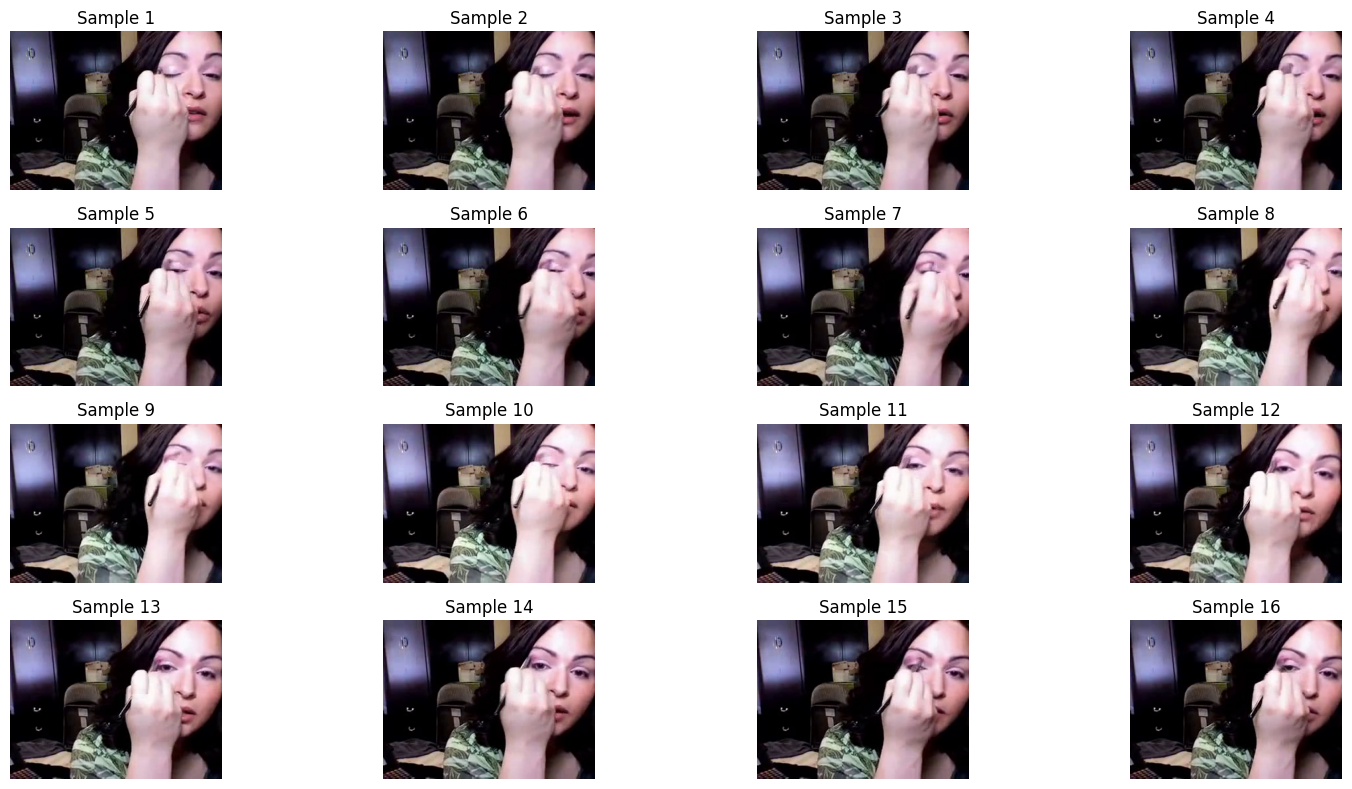

In [28]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(16, 8))

for i, frame in enumerate(sampled_frames):
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.subplot(4, 4, i + 1)
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.title(f"Sample {i + 1}")

plt.tight_layout()
plt.show()

In [29]:
import cv2

IMAGE_SIZE = 112

resized_frames = []

for frame in sampled_frames:
    resized = cv2.resize(
        frame,
        (IMAGE_SIZE, IMAGE_SIZE)
    )
    resized_frames.append(resized)

print("Number of frames:", len(resized_frames))
print("Frame shape:", resized_frames[0].shape)

Number of frames: 16
Frame shape: (112, 112, 3)


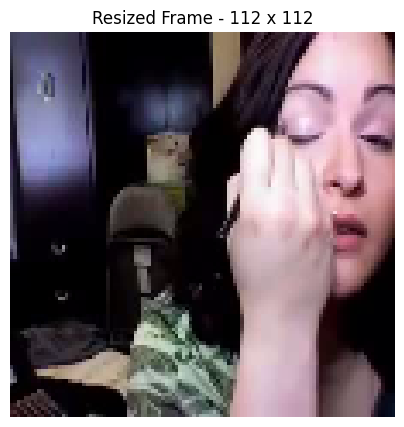

In [30]:
import matplotlib.pyplot as plt
import cv2

frame_rgb = cv2.cvtColor(
    resized_frames[0],
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(5, 5))
plt.imshow(frame_rgb)
plt.axis("off")
plt.title("Resized Frame - 112 x 112")
plt.show()

In [31]:
import numpy as np

normalized_frames = []

for frame in resized_frames:
    normalized = frame.astype(np.float32) / 255.0
    normalized_frames.append(normalized)

print("Number of frames:", len(normalized_frames))
print("Frame shape:", normalized_frames[0].shape)
print("Minimum value:", normalized_frames[0].min())
print("Maximum value:", normalized_frames[0].max())

Number of frames: 16
Frame shape: (112, 112, 3)
Minimum value: 0.0
Maximum value: 1.0


In [32]:
import numpy as np
import torch

# Convert list to NumPy array
video_array = np.array(normalized_frames)

print("Before:", video_array.shape)

# Rearrange dimensions
video_array = np.transpose(
    video_array,
    (3, 0, 1, 2)
)

print("After:", video_array.shape)

Before: (16, 112, 112, 3)
After: (3, 16, 112, 112)


In [33]:
video_tensor = torch.tensor(
    video_array,
    dtype=torch.float32
)

print("Tensor shape:", video_tensor.shape)
print("Tensor dtype:", video_tensor.dtype)

Tensor shape: torch.Size([3, 16, 112, 112])
Tensor dtype: torch.float32


In [34]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [35]:
video_tensor = video_tensor.to(device)

print("Tensor device:", video_tensor.device)

Tensor device: cpu


In [36]:
import os

dataset_path = "ucf101_dataset/UCF-101"

class_names = sorted([
    folder
    for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
])

print("Number of classes:", len(class_names))
print("\nFirst 10 classes:")

for i, class_name in enumerate(class_names[:10]):
    print(i, "->", class_name)

Number of classes: 101

First 10 classes:
0 -> ApplyEyeMakeup
1 -> ApplyLipstick
2 -> Archery
3 -> BabyCrawling
4 -> BalanceBeam
5 -> BandMarching
6 -> BaseballPitch
7 -> Basketball
8 -> BasketballDunk
9 -> BenchPress


In [37]:
class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

print("Example mappings:")

for class_name in class_names[:10]:
    print(class_name, "->", class_to_idx[class_name])

Example mappings:
ApplyEyeMakeup -> 0
ApplyLipstick -> 1
Archery -> 2
BabyCrawling -> 3
BalanceBeam -> 4
BandMarching -> 5
BaseballPitch -> 6
Basketball -> 7
BasketballDunk -> 8
BenchPress -> 9


In [38]:
video_samples = []

for class_name in class_names:
    class_path = os.path.join(dataset_path, class_name)

    for file_name in os.listdir(class_path):
        if file_name.lower().endswith((".avi", ".mp4", ".mov")):
            video_path = os.path.join(class_path, file_name)
            label = class_to_idx[class_name]

            video_samples.append(
                (video_path, label)
            )

print("Total video samples:", len(video_samples))

Total video samples: 13320


In [39]:
sample_video, sample_label = video_samples[0]

print("Video:", sample_video)
print("Label index:", sample_label)
print("Label name:", class_names[sample_label])

Video: ucf101_dataset/UCF-101/ApplyEyeMakeup/v_ApplyEyeMakeup_g06_c06.avi
Label index: 0
Label name: ApplyEyeMakeup


In [40]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
train_samples, temp_samples = train_test_split(
    video_samples,
    test_size=0.30,
    random_state=42,
    stratify=[label for _, label in video_samples]
)

# Second split: 15% validation, 15% test
val_samples, test_samples = train_test_split(
    temp_samples,
    test_size=0.50,
    random_state=42,
    stratify=[label for _, label in temp_samples]
)

print("Total samples:", len(video_samples))
print("Training samples:", len(train_samples))
print("Validation samples:", len(val_samples))
print("Test samples:", len(test_samples))

Total samples: 13320
Training samples: 9324
Validation samples: 1998
Test samples: 1998


In [41]:
from collections import Counter

train_distribution = Counter(label for _, label in train_samples)
val_distribution = Counter(label for _, label in val_samples)
test_distribution = Counter(label for _, label in test_samples)

print("Train classes:", len(train_distribution))
print("Validation classes:", len(val_distribution))
print("Test classes:", len(test_distribution))

Train classes: 101
Validation classes: 101
Test classes: 101


In [42]:
print("TRAIN SAMPLE:")
print(train_samples[0])

print("\nVALIDATION SAMPLE:")
print(val_samples[0])

print("\nTEST SAMPLE:")
print(test_samples[0])

TRAIN SAMPLE:
('ucf101_dataset/UCF-101/PullUps/v_PullUps_g07_c03.avi', 69)

VALIDATION SAMPLE:
('ucf101_dataset/UCF-101/LongJump/v_LongJump_g17_c04.avi', 50)

TEST SAMPLE:
('ucf101_dataset/UCF-101/VolleyballSpiking/v_VolleyballSpiking_g14_c03.avi', 96)


In [43]:
import torch
from torch.utils.data import Dataset
import cv2
import numpy as np


class UCF101Dataset(Dataset):

    def __init__(
        self,
        samples,
        num_frames=16,
        image_size=112
    ):
        self.samples = samples
        self.num_frames = num_frames
        self.image_size = image_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):

        video_path, label = self.samples[index]

        cap = cv2.VideoCapture(video_path)

        frames = []

        while True:
            success, frame = cap.read()

            if not success:
                break

            frames.append(frame)

        cap.release()

        # Handle videos with no frames
        if len(frames) == 0:
            raise RuntimeError(
                f"Could not read video: {video_path}"
            )

        # Temporal sampling
        indices = np.linspace(
            0,
            len(frames) - 1,
            self.num_frames
        ).astype(int)

        sampled_frames = [
            frames[i] for i in indices
        ]

        processed_frames = []

        for frame in sampled_frames:

            # Resize
            frame = cv2.resize(
                frame,
                (self.image_size, self.image_size)
            )

            # Normalize
            frame = frame.astype(
                np.float32
            ) / 255.0

            processed_frames.append(frame)

        # Convert to NumPy
        video = np.array(
            processed_frames,
            dtype=np.float32
        )

        # T,H,W,C → C,T,H,W
        video = np.transpose(
            video,
            (3, 0, 1, 2)
        )

        # NumPy → PyTorch Tensor
        video = torch.tensor(
            video,
            dtype=torch.float32
        )

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return video, label

In [44]:
train_dataset = UCF101Dataset(
    train_samples,
    num_frames=16,
    image_size=112
)

print("Training dataset size:", len(train_dataset))

Training dataset size: 9324


In [45]:
video_tensor, label = train_dataset[0]

print("Video tensor shape:", video_tensor.shape)
print("Label:", label.item())
print("Class:", class_names[label.item()])

Video tensor shape: torch.Size([3, 16, 112, 112])
Label: 69
Class: PullUps


In [46]:
val_dataset = UCF101Dataset(
    val_samples,
    num_frames=16,
    image_size=112
)

test_dataset = UCF101Dataset(
    test_samples,
    num_frames=16,
    image_size=112
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 9324
Validation: 1998
Test: 1998


In [47]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


In [48]:
videos, labels = next(iter(train_loader))

print("Batch video shape:", videos.shape)
print("Batch labels shape:", labels.shape)
print("Labels:", labels)

Batch video shape: torch.Size([4, 3, 16, 112, 112])
Batch labels shape: torch.Size([4])
Labels: tensor([41, 33, 47, 73])


In [49]:
import torch
import torch.nn as nn


class ActionRecognition3DCNN(nn.Module):

    def __init__(self, num_classes=101):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv3d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool3d(
                kernel_size=2
            ),

            # Block 2
            nn.Conv3d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool3d(
                kernel_size=2
            ),

            # Block 3
            nn.Conv3d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU()
        )

        self.global_pool = nn.AdaptiveAvgPool3d(
            (1, 1, 1)
        )

        self.classifier = nn.Linear(
            128,
            num_classes
        )

    def forward(self, x):

        x = self.features(x)

        x = self.global_pool(x)

        x = torch.flatten(
            x,
            start_dim=1
        )

        x = self.classifier(x)

        return x

In [50]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = ActionRecognition3DCNN(
    num_classes=101
)

model = model.to(device)

print(model)

ActionRecognition3DCNN(
  (features): Sequential(
    (0): Conv3d(3, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): ReLU()
    (2): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (4): ReLU()
    (5): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv3d(64, 128, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (7): ReLU()
  )
  (global_pool): AdaptiveAvgPool3d(output_size=(1, 1, 1))
  (classifier): Linear(in_features=128, out_features=101, bias=True)
)


In [51]:
videos, labels = next(iter(train_loader))

videos = videos.to(device)

with torch.no_grad():
    outputs = model(videos)

print("Input shape:", videos.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([4, 3, 16, 112, 112])
Output shape: torch.Size([4, 101])


In [52]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

print("Loss function:", criterion)

Loss function: CrossEntropyLoss()


In [53]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Optimizer:", optimizer)

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [54]:
model.train()

videos, labels = next(iter(train_loader))

videos = videos.to(device)
labels = labels.to(device)

outputs = model(videos)

loss = criterion(outputs, labels)

print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)
print("Loss:", loss.item())

Output shape: torch.Size([4, 101])
Labels shape: torch.Size([4])
Loss: 4.646394729614258


In [55]:
optimizer.zero_grad()

outputs = model(videos)

loss = criterion(outputs, labels)

loss.backward()

optimizer.step()

print("One training update completed.")
print("Loss:", loss.item())

One training update completed.
Loss: 4.646394729614258


In [ ]:
NUM_EPOCHS = 1

for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for videos, labels in train_loader:

        videos = videos.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(videos)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            dim=1
        )

        total += labels.size(0)
        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = (
        running_loss / len(train_loader)
    )

    epoch_accuracy = (
        100 * correct / total
    )

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Loss: {epoch_loss:.4f} "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

In [ ]:

!pwd
!ls